In [35]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style("whitegrid")
df = pd.read_csv("cs-training.csv")

print(df.head())

   Unnamed: 0  SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines  age  \
0           1                 1                              0.766127   45   
1           2                 0                              0.957151   40   
2           3                 0                              0.658180   38   
3           4                 0                              0.233810   30   
4           5                 0                              0.907239   49   

   NumberOfTime30-59DaysPastDueNotWorse  DebtRatio  MonthlyIncome  \
0                                     2   0.802982         9120.0   
1                                     0   0.121876         2600.0   
2                                     1   0.085113         3042.0   
3                                     0   0.036050         3300.0   
4                                     1   0.024926        63588.0   

   NumberOfOpenCreditLinesAndLoans  NumberOfTimes90DaysLate  \
0                               13                   

In [36]:
df.columns

Index(['Unnamed: 0', 'SeriousDlqin2yrs',
       'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents'],
      dtype='object')

In [37]:
df.shape

(150000, 12)

In [38]:
df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [39]:
df.drop(columns=['Unnamed: 0'], inplace=True)

In [40]:
df = df.rename(columns={
    'SeriousDlqin2yrs': 'Default_in_2yrs',
    'RevolvingUtilizationOfUnsecuredLines': 'CreditUtilization',
    'age': 'Age',
    'NumberOfTime30-59DaysPastDueNotWorse': 'Num_30_59_DaysLate',
    'DebtRatio': 'DebtRatio',
    'MonthlyIncome': 'MonthlyIncome',
    'NumberOfOpenCreditLinesAndLoans': 'Num_OpenCreditLinesLoans',
    'NumberOfTimes90DaysLate': 'Num_90_DaysLate',
    'NumberRealEstateLoansOrLines': 'Num_RealEstateLoans',
    'NumberOfTime60-89DaysPastDueNotWorse': 'Num_60_89_DaysLate',
    'NumberOfDependents': 'Num_Dependents'
})

print(df.columns)



Index(['Default_in_2yrs', 'CreditUtilization', 'Age', 'Num_30_59_DaysLate',
       'DebtRatio', 'MonthlyIncome', 'Num_OpenCreditLinesLoans',
       'Num_90_DaysLate', 'Num_RealEstateLoans', 'Num_60_89_DaysLate',
       'Num_Dependents'],
      dtype='object')


In [41]:
df.head()

,Default_in_2yrs,CreditUtilization,Age,Num_30_59_DaysLate,DebtRatio,MonthlyIncome,Num_OpenCreditLinesLoans,Num_90_DaysLate,Num_RealEstateLoans,Num_60_89_DaysLate,Num_Dependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Default_in_2yrs           150000 non-null  int64  
 1   CreditUtilization         150000 non-null  float64
 2   Age                       150000 non-null  int64  
 3   Num_30_59_DaysLate        150000 non-null  int64  
 4   DebtRatio                 150000 non-null  float64
 5   MonthlyIncome             120269 non-null  float64
 6   Num_OpenCreditLinesLoans  150000 non-null  int64  
 7   Num_90_DaysLate           150000 non-null  int64  
 8   Num_RealEstateLoans       150000 non-null  int64  
 9   Num_60_89_DaysLate        150000 non-null  int64  
 10  Num_Dependents            146076 non-null  float64
dtypes: float64(4), int64(7)
memory usage: 12.6 MB


In [43]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Default_in_2yrs,150000.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.0
CreditUtilization,150000.0,6.048438,249.755371,0.0,0.029867,0.154181,0.559046,50708.0
Age,150000.0,52.295207,14.771866,0.0,41.000000,52.000000,63.000000,109.0
Num_30_59_DaysLate,150000.0,0.421033,4.192781,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,150000.0,353.005076,2037.818523,0.0,0.175074,0.366508,0.868254,329664.0
MonthlyIncome,120269.0,6670.221237,14384.674215,0.0,3400.000000,5400.000000,8249.000000,3008750.0
Num_OpenCreditLinesLoans,150000.0,8.452760,5.145951,0.0,5.000000,8.000000,11.000000,58.0
Num_90_DaysLate,150000.0,0.265973,4.169304,0.0,0.000000,0.000000,0.000000,98.0
Num_RealEstateLoans,150000.0,1.018240,1.129771,0.0,0.000000,1.000000,2.000000,54.0
Num_60_89_DaysLate,150000.0,0.240387,4.155179,0.0,0.000000,0.000000,0.000000,98.0


In [44]:
df.isnull().sum()/len(df) * 100

Default_in_2yrs              0.000000
CreditUtilization            0.000000
Age                          0.000000
Num_30_59_DaysLate           0.000000
DebtRatio                    0.000000
MonthlyIncome               19.820667
Num_OpenCreditLinesLoans     0.000000
Num_90_DaysLate              0.000000
Num_RealEstateLoans          0.000000
Num_60_89_DaysLate           0.000000
Num_Dependents               2.616000
dtype: float64

In [45]:
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(df['MonthlyIncome'].mean())
df['Num_Dependents'] = df['Num_Dependents'].fillna(df['Num_Dependents'].mode()[0])


In [46]:
df.isnull().sum()/len(df) * 100

Default_in_2yrs             0.0
CreditUtilization           0.0
Age                         0.0
Num_30_59_DaysLate          0.0
DebtRatio                   0.0
MonthlyIncome               0.0
Num_OpenCreditLinesLoans    0.0
Num_90_DaysLate             0.0
Num_RealEstateLoans         0.0
Num_60_89_DaysLate          0.0
Num_Dependents              0.0
dtype: float64

In [47]:
print(df.nunique())

Default_in_2yrs                  2
CreditUtilization           125728
Age                             86
Num_30_59_DaysLate              16
DebtRatio                   114194
MonthlyIncome                13595
Num_OpenCreditLinesLoans        58
Num_90_DaysLate                 19
Num_RealEstateLoans             28
Num_60_89_DaysLate              13
Num_Dependents                  13
dtype: int64


In [48]:
df.duplicated().sum()

767

In [49]:
df = df.drop_duplicates()
df.duplicated().sum()

0

In [50]:
df.dtypes

Default_in_2yrs               int64
CreditUtilization           float64
Age                           int64
Num_30_59_DaysLate            int64
DebtRatio                   float64
MonthlyIncome               float64
Num_OpenCreditLinesLoans      int64
Num_90_DaysLate               int64
Num_RealEstateLoans           int64
Num_60_89_DaysLate            int64
Num_Dependents              float64
dtype: object

Correlation Matrix
                          Default_in_2yrs  CreditUtilization       Age  \
Default_in_2yrs                  1.000000          -0.001822 -0.115569   
CreditUtilization               -0.001822           1.000000 -0.005934   
Age                             -0.115569          -0.005934  1.000000   
Num_30_59_DaysLate               0.131798          -0.001287 -0.053706   
DebtRatio                       -0.007747           0.003942  0.024322   
MonthlyIncome                   -0.018081           0.006559  0.032615   
Num_OpenCreditLinesLoans        -0.030727          -0.011487  0.147859   
Num_90_DaysLate                  0.122627          -0.001002 -0.051430   
Num_RealEstateLoans             -0.007771           0.006144  0.033255   
Num_60_89_DaysLate               0.106064          -0.000987 -0.047131   
Num_Dependents                   0.046461           0.001119 -0.217475   

                          Num_30_59_DaysLate  DebtRatio  MonthlyIncome  \
Default_in_2yrs   

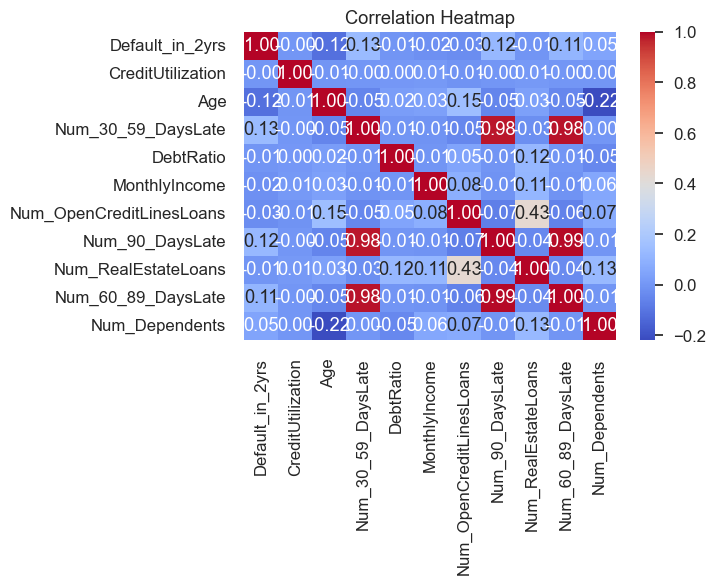

In [51]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numeric_cols].corr()

print("Correlation Matrix")
print(corr_matrix)

plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [52]:
df.drop(columns=['Num_30_59_DaysLate','Num_60_89_DaysLate'], inplace=True)

In [53]:
df.head()

,Default_in_2yrs,CreditUtilization,Age,DebtRatio,MonthlyIncome,Num_OpenCreditLinesLoans,Num_90_DaysLate,Num_RealEstateLoans,Num_Dependents
0,1,0.766127,45,0.802982,9120.0,13,0,6,2.0
1,0,0.957151,40,0.121876,2600.0,4,0,0,1.0
2,0,0.658180,38,0.085113,3042.0,2,1,0,0.0
3,0,0.233810,30,0.036050,3300.0,5,0,0,0.0
4,0,0.907239,49,0.024926,63588.0,7,0,1,0.0


Correlation Matrix
                          Default_in_2yrs  CreditUtilization       Age  \
Default_in_2yrs                  1.000000          -0.001822 -0.115569   
CreditUtilization               -0.001822           1.000000 -0.005934   
Age                             -0.115569          -0.005934  1.000000   
DebtRatio                       -0.007747           0.003942  0.024322   
MonthlyIncome                   -0.018081           0.006559  0.032615   
Num_OpenCreditLinesLoans        -0.030727          -0.011487  0.147859   
Num_90_DaysLate                  0.122627          -0.001002 -0.051430   
Num_RealEstateLoans             -0.007771           0.006144  0.033255   
Num_Dependents                   0.046461           0.001119 -0.217475   

                          DebtRatio  MonthlyIncome  Num_OpenCreditLinesLoans  \
Default_in_2yrs           -0.007747      -0.018081                 -0.030727   
CreditUtilization          0.003942       0.006559                 -0.011487   


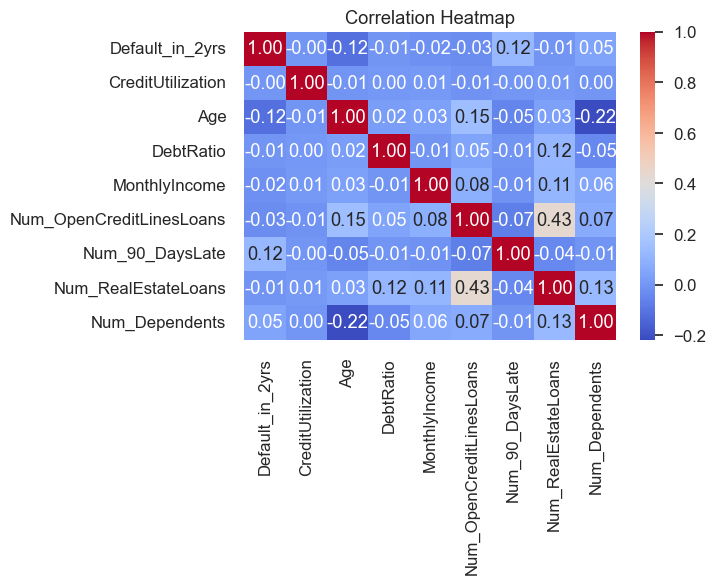

In [54]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numeric_cols].corr()

print("Correlation Matrix")
print(corr_matrix)

plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

C:\Users\ENG-YOSRE\AppData\Local\Temp\ipykernel_14732\4177397893.py:1: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use("seaborn")


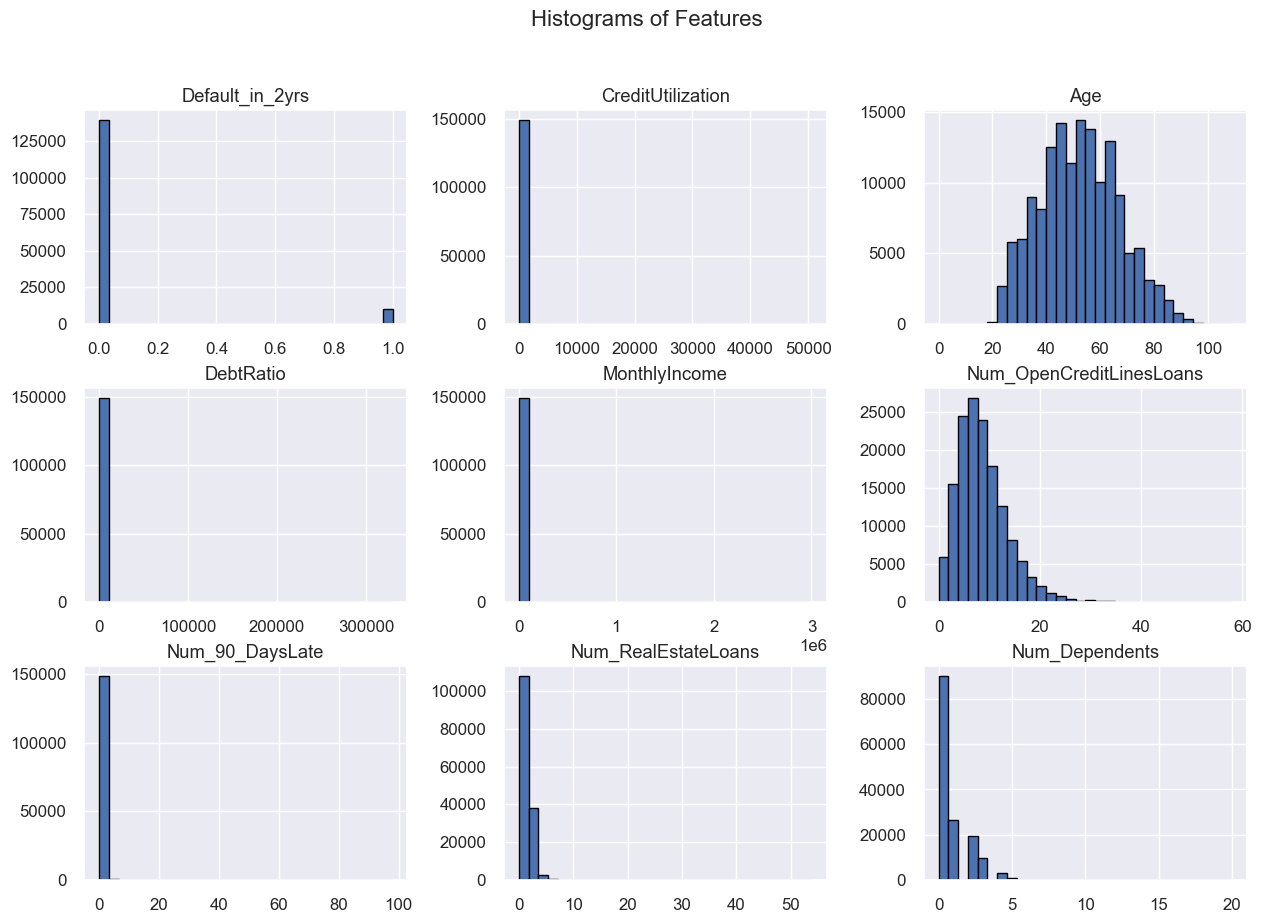

e:\المبادرة\AI\week 5\venv\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


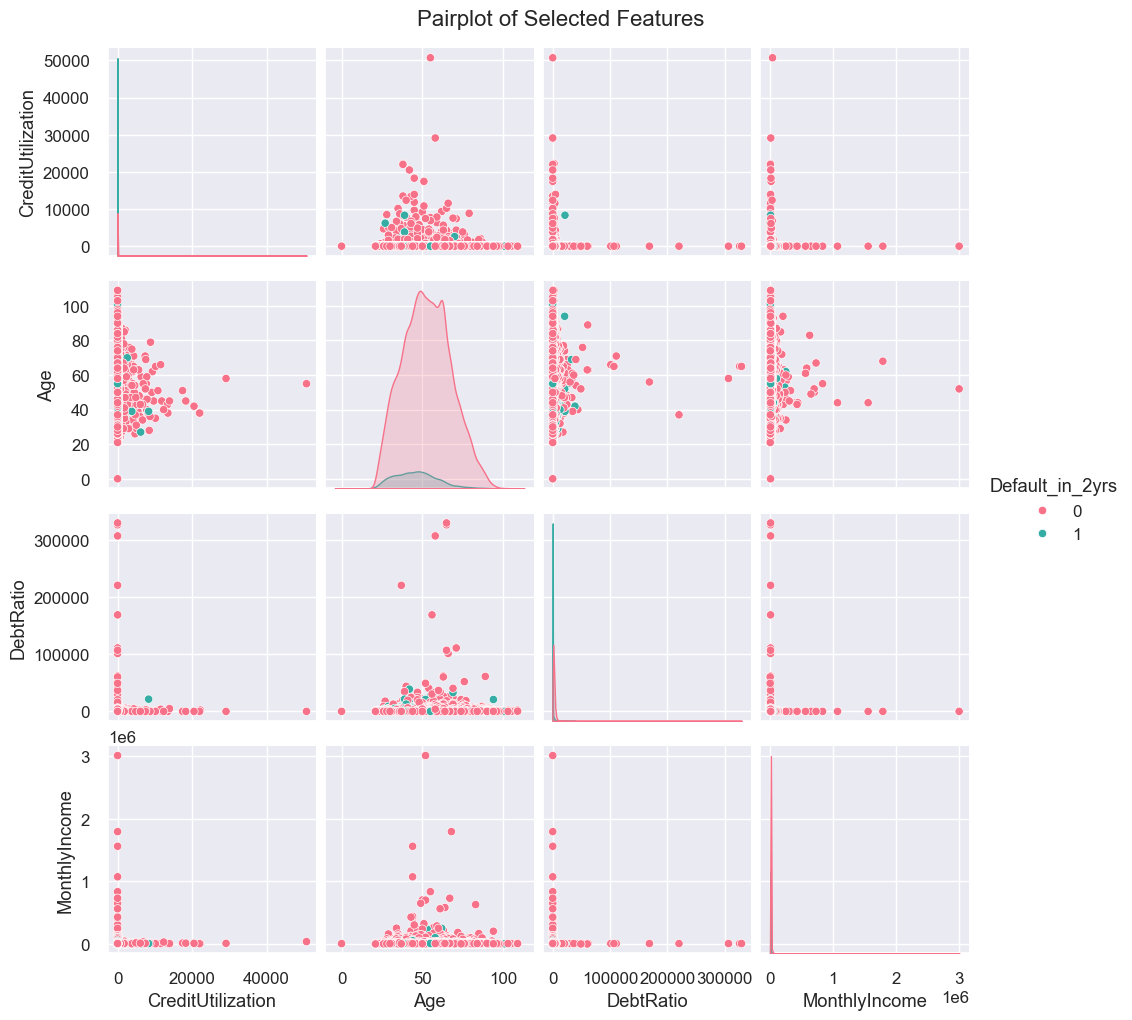

C:\Users\ENG-YOSRE\AppData\Local\Temp\ipykernel_14732\4177397893.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Default_in_2yrs", data=df, palette="Set2")


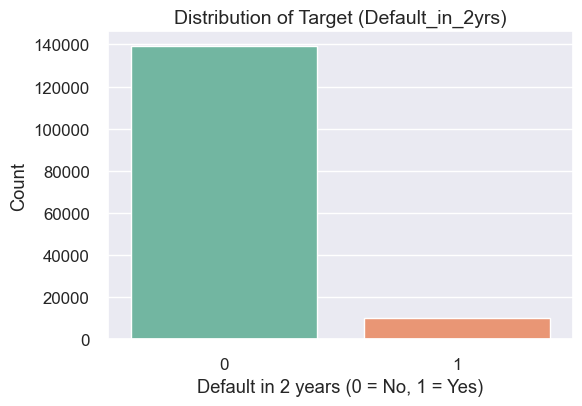

In [55]:
plt.style.use("seaborn")
sns.set(font_scale=1.1)

# -----------------------------
# 1. Histogram لكل feature
# -----------------------------
df.hist(figsize=(15, 10), bins=30, edgecolor="black")
plt.suptitle("Histograms of Features", fontsize=16)
plt.show()

# -----------------------------
# 2. Pairplot
# -----------------------------
selected_cols = ["CreditUtilization", "Age", "DebtRatio", "MonthlyIncome", "Default_in_2yrs"]
sns.pairplot(df[selected_cols], hue="Default_in_2yrs", diag_kind="kde", palette="husl")
plt.suptitle("Pairplot of Selected Features", y=1.02, fontsize=16)
plt.show()

# -----------------------------
# 3. Countplot للـ Target
# -----------------------------
plt.figure(figsize=(6,4))
sns.countplot(x="Default_in_2yrs", data=df, palette="Set2")
plt.title("Distribution of Target (Default_in_2yrs)", fontsize=14)
plt.xlabel("Default in 2 years (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()


Default_in_2yrs                Axes(0.125,0.747241;0.133621x0.132759)
CreditUtilization           Axes(0.285345,0.747241;0.133621x0.132759)
Age                          Axes(0.44569,0.747241;0.133621x0.132759)
DebtRatio                   Axes(0.606034,0.747241;0.133621x0.132759)
MonthlyIncome               Axes(0.766379,0.747241;0.133621x0.132759)
Num_OpenCreditLinesLoans       Axes(0.125,0.587931;0.133621x0.132759)
Num_90_DaysLate             Axes(0.285345,0.587931;0.133621x0.132759)
Num_RealEstateLoans          Axes(0.44569,0.587931;0.133621x0.132759)
Num_Dependents              Axes(0.606034,0.587931;0.133621x0.132759)
dtype: object

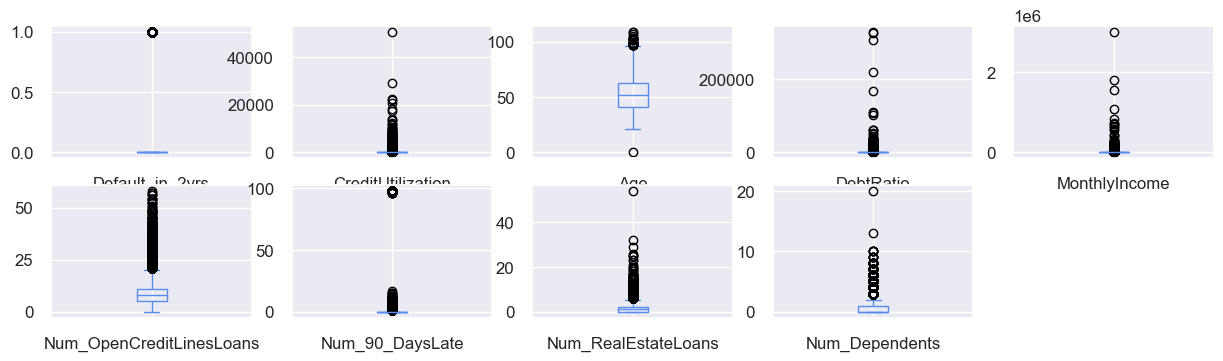

In [56]:
df.plot(kind='box',subplots=True, figsize=(15, 10), color="#578BEC",layout=(5,5))

In [57]:
from sklearn.preprocessing import RobustScaler

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# 1. Winsorization (قص القيم عند 1% و 99%)
for col in num_cols:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = np.clip(df[col], lower, upper)

# 2. Log transformation للأعمدة skewed
skewed_cols = ['MonthlyIncome', 'DebtRatio']  
for col in skewed_cols:
    df[col] = np.log1p(df[col])  


Default_in_2yrs                Axes(0.125,0.747241;0.133621x0.132759)
CreditUtilization           Axes(0.285345,0.747241;0.133621x0.132759)
Age                          Axes(0.44569,0.747241;0.133621x0.132759)
DebtRatio                   Axes(0.606034,0.747241;0.133621x0.132759)
MonthlyIncome               Axes(0.766379,0.747241;0.133621x0.132759)
Num_OpenCreditLinesLoans       Axes(0.125,0.587931;0.133621x0.132759)
Num_90_DaysLate             Axes(0.285345,0.587931;0.133621x0.132759)
Num_RealEstateLoans          Axes(0.44569,0.587931;0.133621x0.132759)
Num_Dependents              Axes(0.606034,0.587931;0.133621x0.132759)
dtype: object

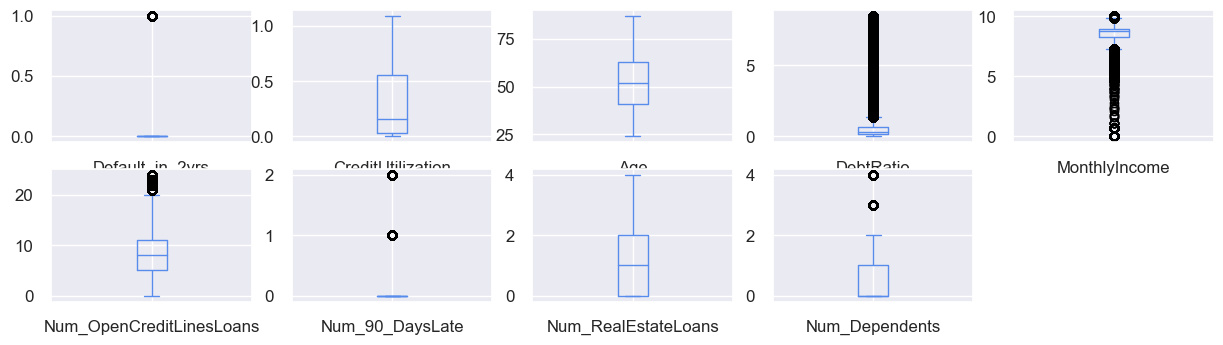

In [58]:
df.plot(kind='box',subplots=True, figsize=(15, 10), color="#578BEC",layout=(5,5))

In [59]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# 1️⃣ Split into train & test BEFORE SMOTE
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2️⃣ Apply SMOTE only on the training set
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_res.value_counts())


Before SMOTE: Default_in_2yrs
0    111383
1      8003
Name: count, dtype: int64
After SMOTE: Default_in_2yrs
0    111383
1    111383
Name: count, dtype: int64


In [86]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

# ==============================
# 1️⃣ تقسيم البيانات
# ==============================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==============================
# 2️⃣ MinMax Scaling
# ==============================
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [87]:

from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE

model = LogisticRegression(max_iter=1000)

rfe = RFE(model, n_features_to_select=5)
fit = rfe.fit(X_train, y_train)

print("Selected Features:")
selected_features = X_train.columns[fit.support_]
print(selected_features)

print("\nFeature Ranking (1 = selected):")
for col, rank in zip(X_train.columns, fit.ranking_):
    print(f"{col}: {rank}")


Selected Features:
Index(['Age', 'Num_OpenCreditLinesLoans', 'Num_90_DaysLate',
       'Num_RealEstateLoans', 'Num_Dependents'],
      dtype='object')

Feature Ranking (1 = selected):
CreditUtilization: 2
Age: 1
DebtRatio: 4
MonthlyIncome: 3
Num_OpenCreditLinesLoans: 1
Num_90_DaysLate: 1
Num_RealEstateLoans: 1
Num_Dependents: 1


In [88]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# ✅ Selected features from RFE
selected_features = ['Age', 'Num_OpenCreditLinesLoans', 'Num_90_DaysLate',
                     'Num_RealEstateLoans', 'Num_Dependents']

# 1️⃣ Keep only the selected features
X_selected = X[selected_features]

# 2️⃣ Split train & test
X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)

# 3️⃣ Train Logistic Regression (you can replace with any model)
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_sel, y_train_sel)

# 4️⃣ Predictions
y_pred_sel = model.predict(X_test_sel)

# 5️⃣ Evaluation
print("Train Accuracy:", accuracy_score(y_train_sel, model.predict(X_train_sel)))
print("Test Accuracy:", accuracy_score(y_test_sel, y_pred_sel))
print("\nClassification Report:\n", classification_report(y_test_sel, y_pred_sel))

cm = confusion_matrix(y_test_sel, y_pred_sel)
print("Confusion Matrix:\n", cm)


Train Accuracy: 0.9332920107885346
Test Accuracy: 0.9332596240828224

Classification Report:
               precision    recall  f1-score   support

           0       0.93      1.00      0.97     27846
           1       0.59      0.01      0.03      2001

    accuracy                           0.93     29847
   macro avg       0.76      0.51      0.50     29847
weighted avg       0.91      0.93      0.90     29847

Confusion Matrix:
 [[27826    20]
 [ 1972    29]]


In [89]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# ✅ Selected features from RFE
selected_features = ['Age', 'Num_OpenCreditLinesLoans', 'Num_90_DaysLate',
                     'Num_RealEstateLoans', 'Num_Dependents']

# 1️⃣ Keep only the selected features
X_selected = X[selected_features]

# 2️⃣ Split train & test
X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)

# 3️⃣ Train Logistic Regression (you can replace with any model)
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_sel, y_train_sel)

# 4️⃣ Predictions
y_pred_sel = model.predict(X_test_sel)

# 5️⃣ Evaluation
print("Train Accuracy:", accuracy_score(y_train_sel, model.predict(X_train_sel)))
print("Test Accuracy:", accuracy_score(y_test_sel, y_pred_sel))
print("\nClassification Report:\n", classification_report(y_test_sel, y_pred_sel))

cm = confusion_matrix(y_test_sel, y_pred_sel)
print("Confusion Matrix:\n", cm)


Train Accuracy: 0.9332920107885346
Test Accuracy: 0.9332596240828224

Classification Report:
               precision    recall  f1-score   support

           0       0.93      1.00      0.97     27846
           1       0.59      0.01      0.03      2001

    accuracy                           0.93     29847
   macro avg       0.76      0.51      0.50     29847
weighted avg       0.91      0.93      0.90     29847

Confusion Matrix:
 [[27826    20]
 [ 1972    29]]


In [90]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# ✅ Selected features from RFE
selected_features = ['Age', 'Num_OpenCreditLinesLoans', 'Num_90_DaysLate',
                     'Num_RealEstateLoans', 'Num_Dependents']

# 1️⃣ Keep only the selected features
X_selected = X[selected_features]

# 2️⃣ Split train & test
X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)

# 3️⃣ Train Random Forest
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
rf_model.fit(X_train_sel, y_train_sel)

# 4️⃣ Predictions
y_pred_sel = rf_model.predict(X_test_sel)

# 5️⃣ Evaluation
print("Train Accuracy:", accuracy_score(y_train_sel, rf_model.predict(X_train_sel)))
print("Test Accuracy:", accuracy_score(y_test_sel, y_pred_sel))
print("\nClassification Report:\n", classification_report(y_test_sel, y_pred_sel))

cm = confusion_matrix(y_test_sel, y_pred_sel)
print("Confusion Matrix:\n", cm)


Train Accuracy: 0.8781264134823179
Test Accuracy: 0.8290280430193989

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.87      0.90     27846
           1       0.14      0.29      0.18      2001

    accuracy                           0.83     29847
   macro avg       0.54      0.58      0.54     29847
weighted avg       0.89      0.83      0.86     29847

Confusion Matrix:
 [[24165  3681]
 [ 1422   579]]


Epoch 1/20


e:\المبادرة\AI\week 5\venv\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3731/3731 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.9279 - loss: 0.2474 - val_accuracy: 0.9349 - val_loss: 0.2271
Epoch 2/20
3731/3731 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9337 - loss: 0.2219 - val_accuracy: 0.9364 - val_loss: 0.2102
Epoch 3/20
3731/3731 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9350 - loss: 0.2114 - val_accuracy: 0.9358 - val_loss: 0.2101
Epoch 4/20
3731/3731 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9347 - loss: 0.2092 - val_accuracy: 0.9361 - val_loss: 0.2070
Epoch 5/20
3731/3731 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9349 - loss: 0.2086 - val_accuracy: 0.9357 - val_loss: 0.2090
Epoch 6/20
3731/3731 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9347 - loss: 0.2085 - val_accuracy: 0.9359 - val_loss: 0.2062
Epoch 7/20
3731/3731 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9349 - loss: 0.2084 - val_accuracy: 0.9361 - val_loss: 0.2057
Epoch 8/20
3731/3731 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9351 - loss: 0.2079 - val_accurac

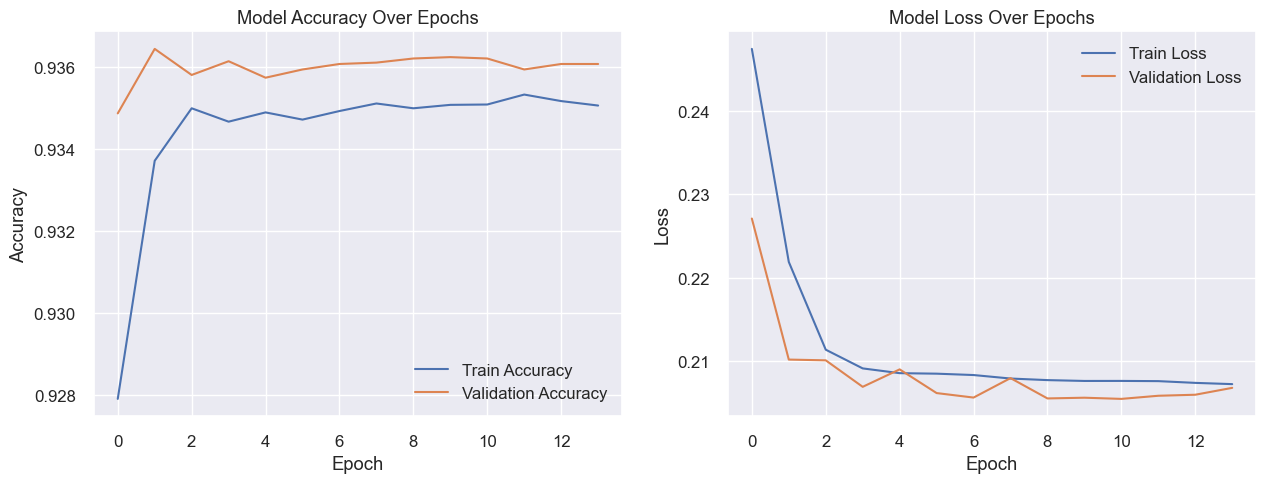

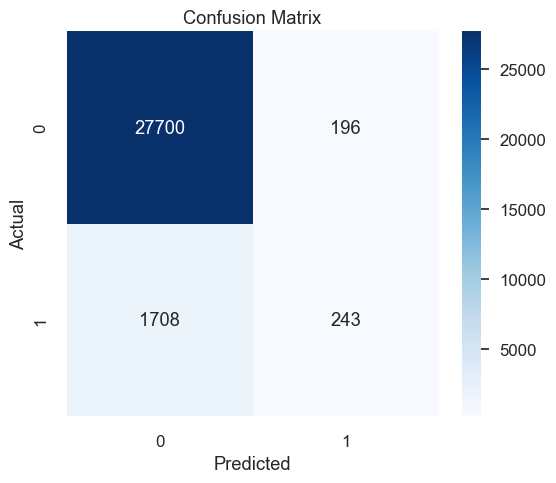

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

dl_model = Sequential([
    Dense(32, input_dim=X_train_scaled.shape[1], activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

dl_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = dl_model.fit(
    X_train_scaled, y_train,
    epochs=20, batch_size=32,
    validation_data=(X_test_scaled, y_test),
    callbacks=[early_stop],
    verbose=1
)


y_pred = (dl_model.predict(X_test_scaled) > 0.5).astype("int32").flatten()

accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"\n✅ ANN with MinMaxScaler")
print(f"Accuracy: {accuracy:.2f}")
print("Classification Report:\n", report)
print("Confusion Matrix:\n", cm)


plt.figure(figsize=(15,5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Confusion Matrix Heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [95]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb
import pandas as pd

# ✅ Selected features from RFE
selected_features = ['Age', 'Num_OpenCreditLinesLoans', 'Num_90_DaysLate',
                     'Num_RealEstateLoans', 'Num_Dependents']

# Keep only selected features
X_selected = X[selected_features]

# Train/Test split
X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)

# Dictionary of models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced"),
    #"SVM": SVC(kernel="rbf", probability=True, class_weight="balanced"),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)
}

results = {}

# Loop over models
for name, model in models.items():
    print("="*50)
    print(f"▶ Training {name}")
    model.fit(X_train_sel, y_train_sel)
    y_pred_sel = model.predict(X_test_sel)

    train_acc = accuracy_score(y_train_sel, model.predict(X_train_sel))
    test_acc = accuracy_score(y_test_sel, y_pred_sel)

    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    print("Classification Report:\n", classification_report(y_test_sel, y_pred_sel))

    cm = confusion_matrix(y_test_sel, y_pred_sel)
    print("Confusion Matrix:\n", cm)

    # Save results
    results[name] = {
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc,
        "Confusion Matrix": cm
    }

# Convert results to DataFrame for easy comparison
results_df = pd.DataFrame(results).T
print("\n\n📊 Summary of Results:")
print(results_df)


▶ Training Logistic Regression
Train Accuracy: 0.7020
Test Accuracy: 0.7010
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.71      0.82     27846
           1       0.13      0.61      0.22      2001

    accuracy                           0.70     29847
   macro avg       0.55      0.66      0.52     29847
weighted avg       0.91      0.70      0.78     29847

Confusion Matrix:
 [[19697  8149]
 [  774  1227]]
▶ Training Random Forest
Train Accuracy: 0.8781
Test Accuracy: 0.8290
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.87      0.90     27846
           1       0.14      0.29      0.18      2001

    accuracy                           0.83     29847
   macro avg       0.54      0.58      0.54     29847
weighted avg       0.89      0.83      0.86     29847

Confusion Matrix:
 [[24165  3681]
 [ 1422   579]]
▶ Training KNN
Train Accuracy: 0.9402
Test Accuracy:

e:\المبادرة\AI\week 5\venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:54:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Train Accuracy: 0.9391
Test Accuracy: 0.9344
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.99      0.97     27846
           1       0.54      0.13      0.21      2001

    accuracy                           0.93     29847
   macro avg       0.74      0.56      0.59     29847
weighted avg       0.91      0.93      0.92     29847

Confusion Matrix:
 [[27629   217]
 [ 1742   259]]


📊 Summary of Results:
                    Train Accuracy Test Accuracy              Confusion Matrix
Logistic Regression       0.702042      0.701042  [[19697, 8149], [774, 1227]]
Random Forest             0.878126      0.829028  [[24165, 3681], [1422, 579]]
KNN                       0.940152      0.932757   [[27592, 254], [1753, 248]]
Gradient Boosting         0.936165      0.935337   [[27648, 198], [1732, 269]]
XGBoost                    0.93913      0.934365   [[27629, 217], [1742, 259]]
